# 01 — Exploratory Data Analysis

Load the raw Kaggle dataset, summarize distributions, and visualize the target balance and missingness.

**Inputs**: `data/raw/heart_failure_readmission_dataset.csv` (auto-pulled from Kaggle by `load_raw()`)
**Outputs**: charts saved to `reports/figures/` (optional)


In [1]:
# add the project folder to the path so we can import our own code in src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
# libraries for loading the data and making plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw
from src.viz.plots import plot_target_distribution, plot_missingness
from src.config import TARGET

sns.set_theme()

In [3]:
# load the dataset (downloads from Kaggle the first time, then reads the local copy)
df = load_raw()
print(df.shape)
df.head()

(3000, 16)


,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [4]:
# column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   object 
 14  distance_to_hospital_km 

In [5]:
# summary statistics for every column
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,3000.0,NaN,NaN,NaN,11499.5,866.169729,10000.0,10749.75,11499.5,12249.25,12999.0
age,3000.0,NaN,NaN,NaN,65.254333,14.806465,40.0,52.0,65.0,78.0,90.0
gender,3000,2,Male,1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,2910.0,NaN,NaN,NaN,28.109038,4.949035,8.8,24.8,28.1,31.5,44.9
bnp,3000.0,NaN,NaN,NaN,406.308,232.273101,50.0,225.0,392.0,569.0,1381.0
sodium,2910.0,NaN,NaN,NaN,138.08921,4.031886,124.7,135.3,138.1,140.8,151.6
creatinine,2910.0,NaN,NaN,NaN,1.195082,0.490563,-0.59,0.87,1.2,1.52,2.94
systolic_bp,3000.0,NaN,NaN,NaN,129.588667,20.25712,61.0,116.0,130.0,143.0,196.0
heart_rate,3000.0,NaN,NaN,NaN,79.364,15.269465,19.0,69.0,79.0,90.0,147.0
ace_inhibitor,3000.0,NaN,NaN,NaN,0.521667,0.499614,0.0,0.0,1.0,1.0,1.0


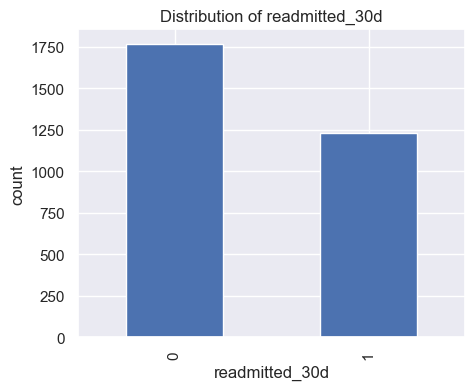

readmitted_30d
0    0.588667
1    0.411333
Name: proportion, dtype: float64

In [6]:
# how balanced is the target? (what fraction of patients were readmitted)
plot_target_distribution(df, TARGET)
plt.show()
df[TARGET].value_counts(normalize=True).rename('proportion')

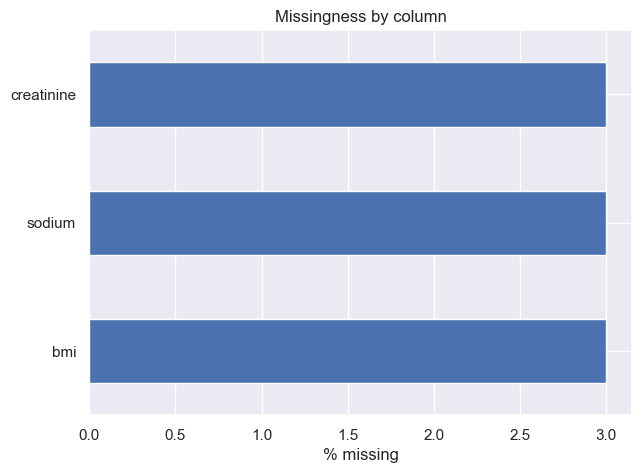

In [7]:
# which columns have missing values, and how much
plot_missingness(df)
plt.show()

## Notes

- Confirm the ~41% positive class proportion reported in the proposal.
- Confirm the ~3% missingness in BMI, sodium, creatinine.
- Look for the negative creatinine values and other extreme outliers flagged in the proposal.
- Numeric distributions: histograms / KDE; categorical: count plots.
